[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


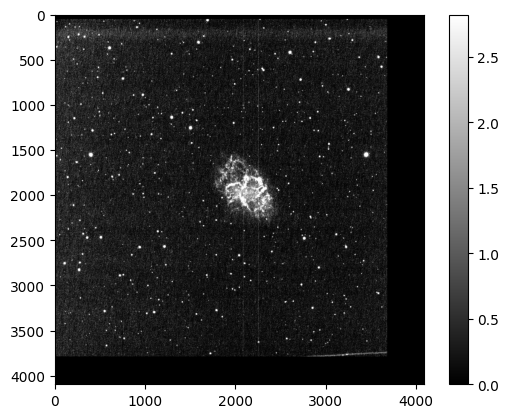

Min: 0.0
Max: 2158.6873
Mean: 0.3201224
Stdev: 3.391315


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from astropy.io import fits

#loads image (not needed for histogram, it is just a check to see if you have the correct image)

image = fits.open('Stacked_master_frame_SII.fits')

image = image[0].data
vmin, vmax = np.percentile(image[~np.isnan(image)], (0.5, 99.5))
print(image)


#shows image

plt.figure()
plt.imshow(image, cmap="gray",vmin = vmin, vmax = vmax )
plt.colorbar()
plt.show()
print("Min:", np.min(image))
print("Max:", np.max(image))
print("Mean:", np.mean(image))
print("Stdev:", np.std(image))


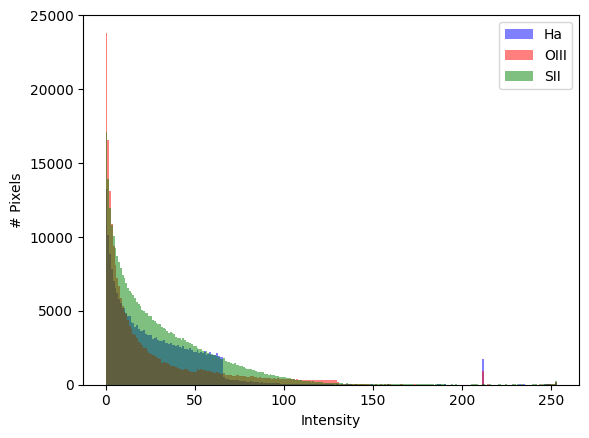

[13260 10119  8853  7803  7027  6516  6227  5775  5552  5197  5195  4844
  4665  4642  4230  4148  3940  4033  3795  3653  3639  3730  3421  3350
  3361  3388  3109  3142  3257  3056  2977  2929  3021  2851  2802  2766
  2853  2717  2660  2588  2679  2535  2468  2605  2442  2433  2336  2471
  2334  2231  2245  2360  2176  2210  2126  2302  2031  2087  2187  2021
  1986  2012  2138  1951  1895  1909   551   363   359   348   352   323
   337   314   294   267   281   252   223   213   199   233   179   173
   174   173   150   164   135   134   140   112   113   124   102    99
   103    99    70    81    79    71    69    59    49    42    42    37
    44    43    48    40    30    40    35    38    32    30    29    34
    23    30    20    24    26    30    27    20    15    25    26    10
    20    13    19    16    17    21    12    14    22    13    12    17
     8    10    10     5    12    20     5     8    11     9     5     8
     8     2    32    15    15     6     6    11   

In [ ]:
# reads image and draws a box around the desired region to create a histogram of the pixel values in that region

imageHa = cv.imread('stacked_master_frame_Ha.png')
regionHa = imageHa[2129:2930, 1894:2746]
valsHa = regionHa.mean(axis=2).flatten()

imageOIII = cv.imread('stacked_master_frame_OIII.png')
regionOIII = imageOIII[1400:2300, 1500:2500]
valsOIII = regionOIII.mean(axis=2).flatten()

imageSII = cv.imread('stacked_master_frame_SII.png')
regionSII = imageSII[1500:2200, 1500:2300]
valsSII = regionSII.mean(axis=2).flatten()


# creates histogram of pixel values in the region

countsHa, binsHa = np.histogram(valsHa, range(1, 255))
countsOIII, binsOIII = np.histogram(valsOIII, range(1, 255))
countsSII, binsSII = np.histogram(valsSII, range(1, 255))


#shows histogram

plt.bar(binsHa[:-1] - 0.5, countsHa, width=1, label = 'Ha',alpha = 0.5, color='b')
plt.bar(binsOIII[:-1] - 0.5, countsOIII, width=1, alpha = 0.5, label = 'OIII', color='r')
plt.bar(binsSII[:-1] - 0.5, countsSII, width=1, alpha = 0.5, label = 'SII', color = 'g')
plt.xlabel('Intensity')
plt.ylabel('# Pixels')
plt.legend()
plt.show()
# print(countsHa)
# print(countsOIII)
# print(countsSII)

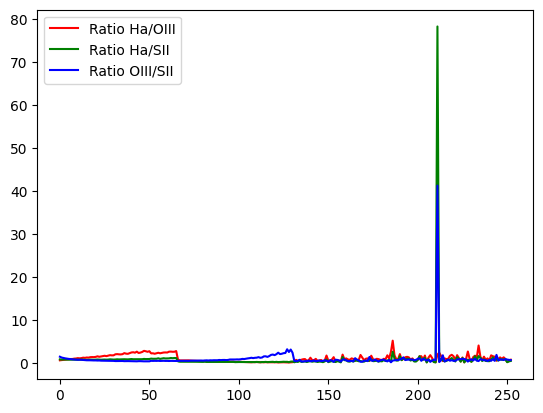

In [ ]:
# calculates ratios of the histograms

ratio1 = np.array(countsHa) / np.array(countsOIII)
ratio2 = np.array(countsHa) / np.array(countsSII)
ratio3 = np.array(countsOIII) / np.array(countsSII)


# shows ratios of the histograms

plt.plot(ratio1, 'r', label = 'Ratio Ha/OIII')
plt.plot(ratio2, 'g', label = 'Ratio Ha/SII')
plt.plot(ratio3, 'b', label = 'Ratio OIII/SII')
plt.legend()
plt.show()